# Quora Duplicate Question Detection

## Classical Machine Learning Models

This notebook trains and evaluates classical supervised models using the
preprocessed datasets created in `01_data_preparation_eda.ipynb`.

## Project Setup and Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\ML\quora-duplicate-question-detection


In [2]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from src.config import (
    processed_train_file,
    processed_test_file,
    results_file,
)
from src.evaluation import evaluate_binary_classifier

import os

In [4]:
RANDOMSEED = 42

In [5]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass

## TF-IDF + Logistic Regression

### Load Preprocessed Data

In [6]:
processed_train = pd.read_parquet(
    processed_train_file
)

processed_test = pd.read_parquet(
    processed_test_file
)

train_data = (
    processed_train[
        processed_train["split"] == "train"
    ]
    .copy()
)

valid_data = (
    processed_train[
        processed_train["split"] == "valid"
    ]
    .copy()
)

print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", processed_test.shape)

Train shape: (258743, 11)
Validation shape: (64686, 11)
Test shape: (80858, 10)


In [7]:
y_train = train_data["is_duplicate"].astype(int)
y_valid = valid_data["is_duplicate"].astype(int)

### TF-IDF Feature Construction

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

In [9]:
train_q1 = train_data["question1_tfidf"].fillna("")
train_q2 = train_data["question2_tfidf"].fillna("")

valid_q1 = valid_data["question1_tfidf"].fillna("")
valid_q2 = valid_data["question2_tfidf"].fillna("")

In [ ]:
train_corpus = pd.concat(
    [
        train_q1,
        train_q2
    ],
    ignore_index=True
)

tfidf_vectorizer.fit(train_corpus)

In [11]:
print(
    f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}"
)

Vocabulary size: 342,949


In [12]:
X_train_q1 = tfidf_vectorizer.transform(train_q1)
X_train_q2 = tfidf_vectorizer.transform(train_q2)

X_valid_q1 = tfidf_vectorizer.transform(valid_q1)
X_valid_q2 = tfidf_vectorizer.transform(valid_q2)

In [13]:
X_train_diff = abs(X_train_q1 - X_train_q2)
X_valid_diff = abs(X_valid_q1 - X_valid_q2)

X_train_product = X_train_q1.multiply(X_train_q2)
X_valid_product = X_valid_q1.multiply(X_valid_q2)

X_train_pair = hstack(
    [X_train_diff, X_train_product],
    format="csr"
)

X_valid_pair = hstack(
    [X_valid_diff, X_valid_product],
    format="csr"
)

print("Train pair shape:", X_train_pair.shape)
print("Validation pair shape:", X_valid_pair.shape)

Train pair shape: (258743, 685898)
Validation pair shape: (64686, 685898)


### Logistic Regression Training and Evaluation

In [14]:
tfidf_lr = LogisticRegression(
    solver="saga",
    max_iter=300,
    random_state=RANDOMSEED,
    verbose=1
)

In [ ]:
tfidf_lr.fit(
    X_train_pair,
    y_train
)

valid_pred = tfidf_lr.predict(X_valid_pair)
valid_proba = tfidf_lr.predict_proba(X_valid_pair)[:, 1]

Model: TF-IDF + Logistic Regression

              precision    recall  f1-score   support

           0     0.8372    0.8977    0.8664     40804
           1     0.8005    0.7017    0.7478     23882

    accuracy                         0.8253     64686
   macro avg     0.8189    0.7997    0.8071     64686
weighted avg     0.8236    0.8253    0.8226     64686

accuracy: 0.8253
precision: 0.8005
recall: 0.7017
f1: 0.7478
roc_auc: 0.9039
log_loss: 0.3893


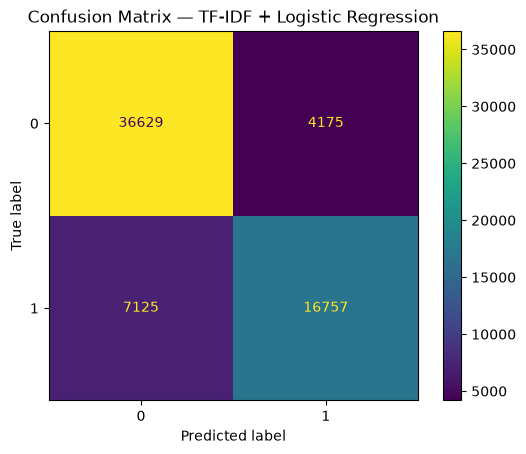

In [16]:
tfidf_lr_metrics = evaluate_binary_classifier(
    model_name="TF-IDF + Logistic Regression",
    y_true=y_valid,
    y_pred=valid_pred,
    y_proba=valid_proba,
)

### Conclusions

- TF-IDF combined with Logistic Regression provides a strong supervised baseline for duplicate-question detection.
- The model achieved a validation ROC-AUC of approximately **0.90**, demonstrating a strong ability to distinguish duplicate and non-duplicate question pairs.
- Precision and recall are reasonably balanced, resulting in a positive-class F1-score of approximately **0.75**.
- The use of both unigram and bigram TF-IDF features allowed the model to capture both lexical overlap and short phrase similarity between questions.
- This model will serve as the baseline for comparison with more advanced approaches in the subsequent experiments.

## Experiment Results

The validation metrics of each model experiment are stored in a shared results
table. Re-running the same experiment replaces its previous result instead of
creating duplicate rows.

In [17]:
result_row = {
    "experiment_id": "tfidf_logreg_baseline",
    "evaluation_split": "validation",
    "feature_set": (
        "TF-IDF word 1-2 grams: "
        "absolute difference + element-wise product"
    ),
    "threshold": 0.5,
    **tfidf_lr_metrics,
}

current_result = pd.DataFrame(
    [result_row]
)

In [18]:
os.makedirs(
    os.path.dirname(results_file),
    exist_ok=True,
)

if os.path.exists(results_file):
    model_results = pd.read_csv(
        results_file
    )

    model_results = model_results[
        model_results["experiment_id"]
        != result_row["experiment_id"]
    ]

    model_results = pd.concat(
        [
            model_results,
            current_result,
        ],
        ignore_index=True,
    )

else:
    model_results = current_result.copy()

In [ ]:
model_results.to_csv(
    results_file,
    index=False,
)

print(f"Results saved to: {results_file}")

In [20]:
model_results_display = (
    model_results.copy()
)

numeric_columns = (
    model_results_display
    .select_dtypes(include="number")
    .columns
)

model_results_display[
    numeric_columns
] = model_results_display[
    numeric_columns
].round(4)

display(model_results_display)

,experiment_id,evaluation_split,feature_set,threshold,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,tfidf_logreg_baseline,validation,TF-IDF word 1-2 grams: absolute difference + e...,0.5,TF-IDF + Logistic Regression,0.8253,0.8005,0.7017,0.7478,0.9039,0.3893
